In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.optim import lr_scheduler
from torch.utils.data import random_split
from torch.utils.data import Subset
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory
from sklearn.model_selection import train_test_split



In [2]:
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

data_augmentation = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [3]:
data_dir = ".."
full_train = datasets.OxfordIIITPet(root=data_dir,split="trainval", transform=data_transform, download=False, target_types="category")
test = datasets.OxfordIIITPet(root=data_dir,split="test", transform=data_transform, download=False, target_types="category")


In [4]:
class_names = full_train.classes

def get_limited_dataloaders(train_dataset, fraction, batch_size=64):
    if fraction == 1.0:
            return DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    labels = [train_dataset.dataset._labels[i] for i in train_dataset.indices]
    selected, _ = train_test_split(train_dataset.indices, train_size=fraction, stratify=labels)
    limited_data = Subset(train_dataset.dataset, selected)
    return DataLoader(limited_data, batch_size=batch_size, shuffle=True, num_workers=0)


train_size = int(0.8 * len(full_train))
val_size = len(full_train) - train_size
train, val = random_split(full_train, [train_size, val_size])

full_train_aug = datasets.OxfordIIITPet(root=data_dir,split="trainval", transform=data_augmentation, download=False, target_types="category")
train_aug = Subset(full_train_aug, train.indices)

val_loader = DataLoader(val, batch_size=64, shuffle=False, num_workers=0)
test_loader = DataLoader(test, batch_size=64, shuffle=False, num_workers=0)


dataloaders = []

fractions = [0.05, 0.1, 1.0]
for frac in fractions:
    train_loader = get_limited_dataloaders(train, frac)
    dataloaders.append({"train": train_loader, "val": val_loader, "test": test_loader})



In [5]:
dataloaders_aug = []
for frac in fractions:
    train_loader = get_limited_dataloaders(train_aug, frac)
    dataloaders_aug.append({"train": train_loader, "val": val_loader, "test": test_loader})

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using {device}")

Using cuda


In [7]:
def evaluate_dataset(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device); labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
    total = len(dataloader.dataset)
    return running_loss / total, (running_corrects.double().item() / total)

In [8]:
def schedule(num_epochs, epoch, epochs_per_stage, l_max):
    layers = min(l_max, epoch// epochs_per_stage + 1)
    update_step = epoch// epochs_per_stage + 1
    
    return layers, update_step

def describe_layers(l):
    names = ["model.fc", "layer4", "layer3", "layer2", "layer1"]
    return names[:l]

def build_optimizer(model, num_layers, weight_decay=1e-4):
    param_groups = []
    param_groups.append({'params': model.fc.parameters(), 'lr': 1e-3})
    if num_layers >= 2:
        param_groups.append({'params': model.layer4.parameters(), 'lr': 1e-4})
    if num_layers >= 3:
        param_groups.append({'params': model.layer3.parameters(), 'lr': 1e-4})
    if num_layers >= 4:
        param_groups.append({'params': model.layer2.parameters(), 'lr': 1e-5})
    if num_layers >= 5:
        param_groups.append({'params': model.layer1.parameters(), 'lr': 1e-5})
    
    return optim.AdamW(param_groups, weight_decay=weight_decay)

In [9]:
def set_finetune_l_layers(model, l):
    #freeze everything first
    for param in model.parameters():
        param.requires_grad = False

    #always unfreeze classifier
    ##for param in model.fc.parameters():
        #param.requires_grad = True

    #ResNet blocks in order from deep layers to shallow
    layers = [model.fc, model.layer4, model.layer3, model.layer2, model.layer1]

    #unfreeze last l blocks
    for i in range(l):
        for param in layers[i].parameters():
            param.requires_grad = True

def train_model(model, criterion, num_epochs,  epochs_per_stage, max_l, dataloaders, weight_decay=1e-4):
    since = time.time()

    train_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0
        prev_update_step = 0
        for epoch in range(num_epochs):
            print(f'Epoch {epoch+1}/{num_epochs}')
            print('-' * 10)
            num_layers, cur_update_step = schedule(num_epochs, epoch, epochs_per_stage, max_l)

            if prev_update_step != cur_update_step:
                prev_update_step = cur_update_step
                set_finetune_l_layers(model, num_layers)
                #trainable_params = [p for p in model.parameters() if p.requires_grad]
                optimizer = build_optimizer(model, num_layers, weight_decay=weight_decay)
            
            print("Trainable parts:", describe_layers(num_layers))
            print("Trainable parameters:",
            sum(p.numel() for p in model.parameters() if p.requires_grad))
            # Each epoch has a training and validation phase

            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)

                epoch_loss = running_loss / len(dataloaders[phase].dataset)
                epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)
                if phase == 'train':
                    train_loss_history.append(epoch_loss)
                    train_acc_history.append(epoch_acc)
                else:
                    val_loss_history.append(epoch_loss)
                    val_acc_history.append(epoch_acc)
                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, map_location=device))
    return model, train_loss_history, val_loss_history, train_acc_history, val_acc_history

In [10]:

def describe_layers(l):
    names = ["layer4", "layer3", "layer2", "layer1"]
    return ["fc"] + names[:l]

def evaluate_on_test(model):
    model.eval()
    running_corrects = 0

    with torch.no_grad():
        for inputs, labels in dataloaders["test"]:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(1)
            running_corrects += (preds == labels).sum().item()

    acc = running_corrects / len(dataloaders["test"].dataset)
    print(f"  Test accuracy: {acc:.4f}")
    return acc

In [11]:
def get_model():
    model = models.resnet34(weights='IMAGENET1K_V1')
    for param in model.parameters():
        param.requires_grad = False
    model.fc = torch.nn.Linear(in_features=512, out_features=37)
    return model.to(device)

model = get_model()

criterion = torch.nn.CrossEntropyLoss()

optimizer_ft = optim.Adam(model.fc.parameters(), lr=0.001)


In [12]:
results_gradual_reg = []
epochs_per_stage = 5
max_l = 5 
total_epochs = epochs_per_stage * max_l  # 25 epochs
for i, fraction in enumerate(fractions):
    print(f"=== Gradual unfreezing, fraction={fraction} ===")
    model = get_model()
    
    criterion = nn.CrossEntropyLoss()
    dataloader = dataloaders[i]
    
    model, train_loss, val_loss, train_acc, val_acc = train_model(
        model, criterion, total_epochs, epochs_per_stage, max_l, dataloader, weight_decay=0
    )
    
    results_gradual_reg.append((fraction, train_loss, val_loss, train_acc, val_acc))

results_gradual_reg_aug = []
for i, fraction in enumerate(fractions):
    print(f"=== Gradual unfreezing, fraction={fraction} ===")
    model = get_model()
    
    criterion = nn.CrossEntropyLoss()
    dataloader = dataloaders_aug[i]
    
    model, train_loss, val_loss, train_acc, val_acc = train_model(
        model, criterion, total_epochs, epochs_per_stage, max_l, dataloader, weight_decay=1e-4
    )
    
    results_gradual_reg_aug.append((fraction, train_loss, val_loss, train_acc, val_acc))

=== Gradual unfreezing, fraction=0.05 ===
Epoch 1/25
----------
Trainable parts: ['fc', 'layer4']
Trainable parameters: 18981
train Loss: 3.8598 Acc: 0.0136
val Loss: 3.4906 Acc: 0.0639
Epoch 2/25
----------
Trainable parts: ['fc', 'layer4']
Trainable parameters: 18981
train Loss: 3.3643 Acc: 0.1088
val Loss: 3.2507 Acc: 0.1196
Epoch 3/25
----------
Trainable parts: ['fc', 'layer4']
Trainable parameters: 18981
train Loss: 3.0202 Acc: 0.2653
val Loss: 3.0426 Acc: 0.1943
Epoch 4/25
----------
Trainable parts: ['fc', 'layer4']
Trainable parameters: 18981
train Loss: 2.7414 Acc: 0.4150
val Loss: 2.8412 Acc: 0.2731
Epoch 5/25
----------
Trainable parts: ['fc', 'layer4']
Trainable parameters: 18981
train Loss: 2.4467 Acc: 0.5646
val Loss: 2.6458 Acc: 0.3872
Epoch 6/25
----------
Trainable parts: ['fc', 'layer4', 'layer3']
Trainable parameters: 13133349
train Loss: 2.1748 Acc: 0.6939
val Loss: 1.9968 Acc: 0.5870
Epoch 7/25
----------
Trainable parts: ['fc', 'layer4', 'layer3']
Trainable param

C:\Users\samyz\AppData\Local\Temp\ipykernel_24080\3207976202.py:102: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_params_path, m

Epoch 1/25
----------
Trainable parts: ['fc', 'layer4']
Trainable parameters: 18981
train Loss: 3.8095 Acc: 0.0238
val Loss: 3.3904 Acc: 0.0924
Epoch 2/25
----------
Trainable parts: ['fc', 'layer4']
Trainable parameters: 18981
train Loss: 3.1817 Acc: 0.2075
val Loss: 3.0145 Acc: 0.2568
Epoch 3/25
----------
Trainable parts: ['fc', 'layer4']
Trainable parameters: 18981
train Loss: 2.7159 Acc: 0.4116
val Loss: 2.6342 Acc: 0.4253
Epoch 4/25
----------
Trainable parts: ['fc', 'layer4']
Trainable parameters: 18981
train Loss: 2.2586 Acc: 0.6599
val Loss: 2.3014 Acc: 0.5829
Epoch 5/25
----------
Trainable parts: ['fc', 'layer4']
Trainable parameters: 18981
train Loss: 1.8807 Acc: 0.7993
val Loss: 2.0423 Acc: 0.6345
Epoch 6/25
----------
Trainable parts: ['fc', 'layer4', 'layer3']
Trainable parameters: 13133349
train Loss: 1.5026 Acc: 0.7789
val Loss: 1.1804 Acc: 0.7459
Epoch 7/25
----------
Trainable parts: ['fc', 'layer4', 'layer3']
Trainable parameters: 13133349
train Loss: 0.5062 Acc: 0.

KeyboardInterrupt: 

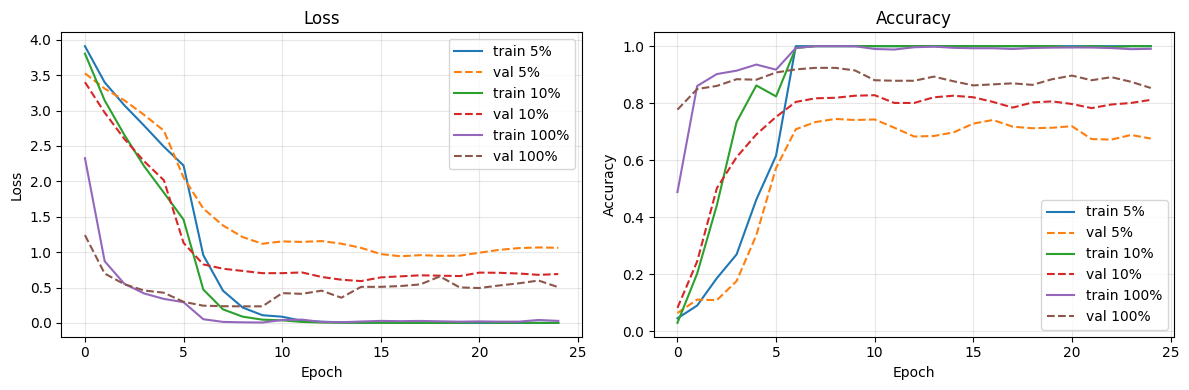

In [ ]:
# # Visualisation simple des resultats d'apprentissage
# import matplotlib.pyplot as plt

# # Accepte les deux noms possibles de variable
# results = results_gradual if 'results_gradual' in globals() else results_gradual

# fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# for fraction, train_loss, val_loss, train_acc, val_acc in results:
#     axes[0].plot(train_loss, label=f"train {fraction:.0%}")
#     axes[0].plot(val_loss, linestyle='--', label=f"val {fraction:.0%}")

#     # train_acc / val_acc peuvent contenir des tenseurs -> conversion float
#     train_acc = [float(x) for x in train_acc]
#     val_acc = [float(x) for x in val_acc]
#     axes[1].plot(train_acc, label=f"train {fraction:.0%}")
#     axes[1].plot(val_acc, linestyle='--', label=f"val {fraction:.0%}")

# axes[0].set_title('Loss')
# axes[0].set_xlabel('Epoch')
# axes[0].set_ylabel('Loss')
# axes[0].legend()
# axes[0].grid(True, alpha=0.3)

# axes[1].set_title('Accuracy')
# axes[1].set_xlabel('Epoch')
# axes[1].set_ylabel('Accuracy')
# axes[1].legend()
# axes[1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig('../results_limited_data/training_curves_gradual.png')
# plt.show()